In [11]:
from data_pipeline import *
import torch_geometric.transforms as T


pre_transform = T.Compose([
    MarkCommonNodes(edge_types=('AD','PD')),
    DuplicateCommonNodesAndRelabel(suffix_ad='_AD', suffix_pd='_PD'),
    ReindexConsecutive(),
    MergeRelationsToHomogeneous(merge=['AD','PD'], edge_attr_reduce='sum'),
    FilterSmallConnectedComponents(topk=2)
])

ds = NeuroDegAnc2VecDataset(root='data', pre_transform=pre_transform)
data = ds[0]

In [12]:
%load_ext autoreload
%autoreload 2


from training_tools.splitter import StratifiedSplitterWithTestHoldout, HoldoutMode
from training_tools.task import TaskBinaryNodeClassification
from training_tools.trainer import Trainer
from training_tools.validation import CrossValidator
from training_tools.evaluation import Evaluator

from models import GCN, GCN_Sage, MLP
import pprint, tqdm

def compare_models_over_repeats(
    data,                   # Data
    model_factories,           # [factory_A, factory_B, ...]
    splitter_ctor,             # lambda seed, mode: StratifiedNestedSplitter(...)
    task, trainer, mode="transductive",
    n = 10
):
    seeds=list(range(n, 2*n))
    # metriche per modello: dict[name] -> list of per-run test F1
    results = {i: [] for i in range(len(model_factories))}
    artifacts_list = []

    with tqdm.tqdm(total=len(seeds), desc="Training Progress", unit="iteration") as pbar:
        for seed in seeds:
            splitter = splitter_ctor(seed, mode)
            parts = splitter.split(data, holdout_mode=HoldoutMode.BFS)

            for idx, factory in enumerate(model_factories):
                cv = CrossValidator(trainer=trainer, model_factory=factory, mode=mode, select_by="f1")
                artifacts, summary = cv.run(task, data, parts)

                evaluator = Evaluator(model_factory=factory, mode=mode)
                test_metrics = evaluator.evaluate(task, data, parts, artifacts["best_state"])
                results[idx].append(test_metrics["f1"])  # metrica primaria
                artifacts_list.append(artifacts)
            pbar.update(1)

    return results, artifacts_list

model_factories = [
    lambda : GCN_Sage(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, num_layers=2, dropout=0),
    lambda : GCN_Sage(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, num_layers=2, dropout=0, head_type="mlp"),
    lambda : GCN_Sage(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, num_layers=2, dropout=0.2),
    lambda : GCN(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0),
    lambda : MLP(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)
]


splitter_ctor = lambda seed, mode: StratifiedSplitterWithTestHoldout(test_size=0.1, n_splits=5, seed=seed, mode=mode)

task    = TaskBinaryNodeClassification(threshold=0.5, pos_weight=None)
trainer = Trainer(lr=1e-3, weight_decay=5e-4, max_epochs=50, patience=5)

results = dict()

results['inductive'], artifacts_list = compare_models_over_repeats(data, model_factories, splitter_ctor, task, trainer, mode='inductive', n=50)
# results['transductive'] = compare_models_over_repeats(data, model_factories, splitter_ctor, task, trainer, mode='transductive', n=20)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Training Progress: 100%|██████████| 50/50 [01:52<00:00,  2.25s/iteration]


In [ ]:
model_names = ["Sage2L", "Sage2L+MLP", "Sage2L+drop", "GCN", "MLP"]

len(artifacts_list)
model_artifacts = {
    "Sage2L" : artifacts_list[:50],
    "Sage2L+MLP" : artifacts_list[50:100],
    "Sage2L+drop" : artifacts_list[100:150],
    "GCN" : artifacts_list[150:200],
    "MLP" : artifacts_list[200:]
}
import random

random_training_per_model = {model : random.choice(artifacts_list) for model, artifacts_list in model_artifacts.items()}

random_training_per_model['Sage2L']

{'per_fold': [{'fold': 0,
   'history': {'epochs_run': 10,
    'best_epoch': 5,
    'best_val_f1': 0.7272727272727273,
    'train': [{'accuracy': 0.53,
      'precision': 1.0,
      'recall': 0.09615384615384616,
      'f1': 0.17543859649122806,
      'loss': 0.7256529927253723},
     {'accuracy': 0.53,
      'precision': 1.0,
      'recall': 0.09615384615384616,
      'f1': 0.17543859649122806,
      'loss': 0.6528107523918152},
     {'accuracy': 0.59,
      'precision': 1.0,
      'recall': 0.21153846153846154,
      'f1': 0.3492063492063492,
      'loss': 0.5893961191177368},
     {'accuracy': 0.75,
      'precision': 1.0,
      'recall': 0.5192307692307693,
      'f1': 0.6835443037974683,
      'loss': 0.5916879773139954},
     {'accuracy': 0.76,
      'precision': 0.9666666666666667,
      'recall': 0.5576923076923077,
      'f1': 0.7073170731707317,
      'loss': 0.5303876399993896},
     {'accuracy': 0.76,
      'precision': 0.9375,
      'recall': 0.5769230769230769,
      'f1'

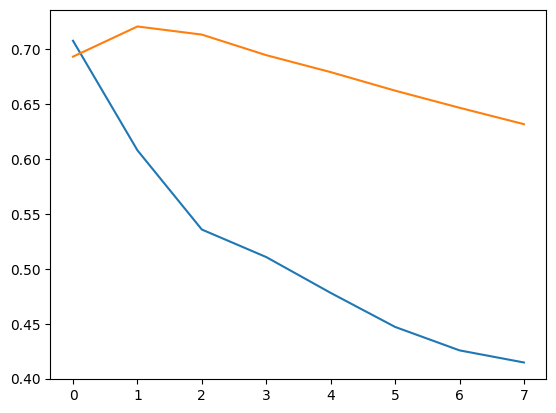

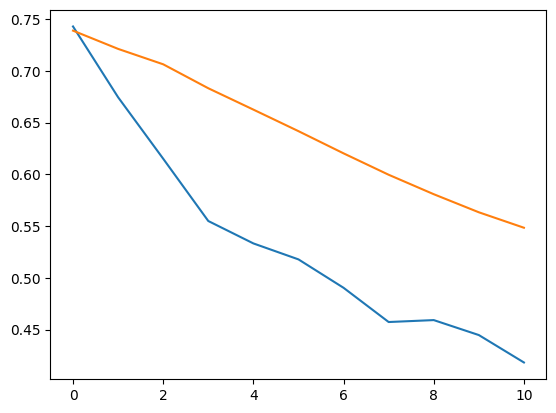

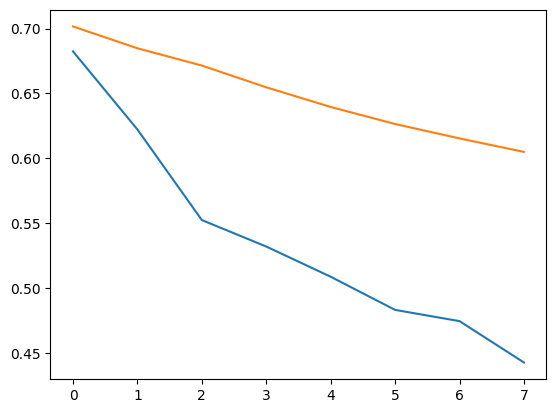

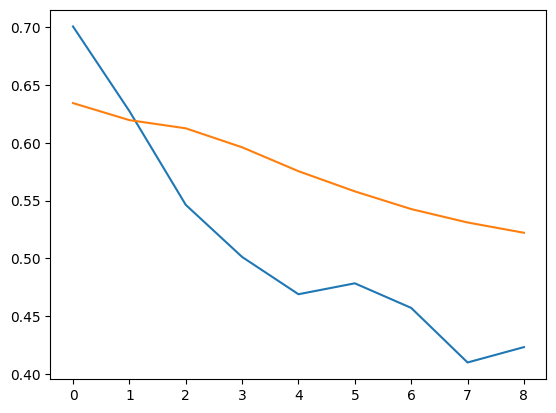

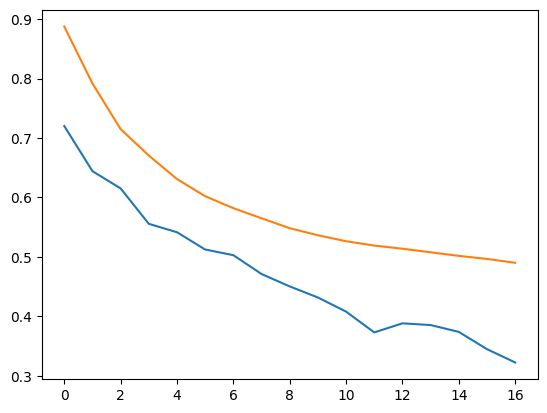

In [24]:
for fold in random_training_per_model['Sage2L+drop']['per_fold']:
    train_art = [art['loss'] for art in fold['history']['train']]
    val_art = [art['loss'] for art in fold['history']['val']]

    x_train = [x for x in range(len(train_art))]
    x_val = [x for x in range(len(val_art))]

    import matplotlib.pyplot as plt

    plt.plot(x_train, train_art)
    plt.plot(x_val, val_art)
    plt.show()

In [ ]:
len(artifacts_list['per_fold'])

5

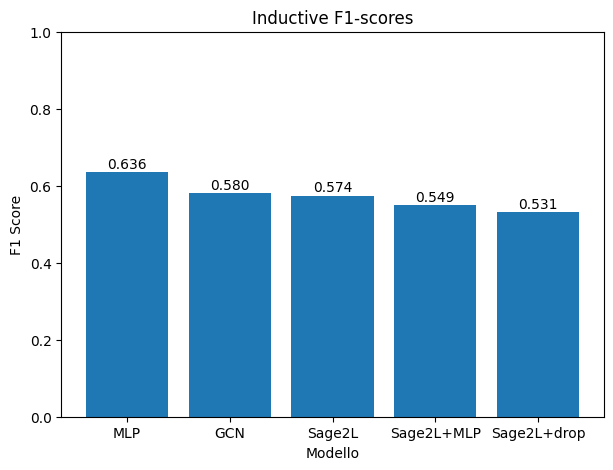

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# model_names = [model().__class__.__name__ for model in model_factories]
model_names = ["Sage2L", "Sage2L+MLP", "Sage2L+drop", "GCN", "MLP"]

# formatted_transductive  = dict(zip(model_names, [np.array(res).mean() for _, res in results['transductive'].items()]))
formatted_inductive     = dict(zip(model_names, [np.array(res).mean() for _, res in results['inductive'].items()]))


def plot_f1(formatted, title):
    sorted_formatted = dict(sorted(formatted.items(), key=lambda x: x[1], reverse=True))

    names = list(sorted_formatted.keys())
    values = list(sorted_formatted.values())

    plt.figure(figsize=(7, 5))
    plt.bar(names, values)
    plt.title(title)
    plt.ylabel("F1 Score")
    plt.xlabel("Modello")
    plt.ylim(0, 1)  # opzionale

    for i, v in enumerate(values):
        plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

    plt.show()

# plot_f1(formatted_transductive  , title='Trasductive F1-scores')
plot_f1(formatted_inductive     , title='Inductive F1-scores')


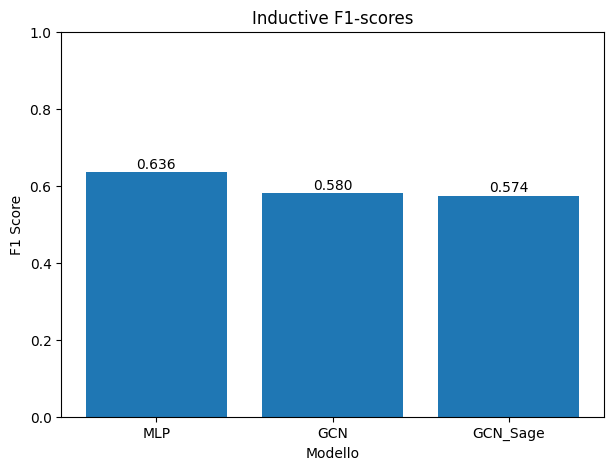

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# model_names = [model().__class__.__name__ for model in model_factories]
model_names = ["GCN_Sage", "Sage2L+MLP", "Sage3L", "GCN", "MLP"]

# formatted_transductive  = dict(zip(model_names, [np.array(res).mean() for _, res in results['transductive'].items()]))
formatted_inductive     = dict(zip(model_names, [np.array(res).mean() for _, res in results['inductive'].items()]))


def plot_f1(formatted, title):
    sorted_formatted = dict(sorted(formatted.items(), key=lambda x: x[1], reverse=True))

    del sorted_formatted['Sage2L+MLP']
    del sorted_formatted['Sage3L']

    names = list(sorted_formatted.keys())
    values = list(sorted_formatted.values())

    plt.figure(figsize=(7, 5))
    plt.bar(names, values)
    plt.title(title)
    plt.ylabel("F1 Score")
    plt.xlabel("Modello")
    plt.ylim(0, 1)  # opzionale

    for i, v in enumerate(values):
        plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

    plt.show()

# plot_f1(formatted_transductive  , title='Trasductive F1-scores')
plot_f1(formatted_inductive     , title='Inductive F1-scores')
